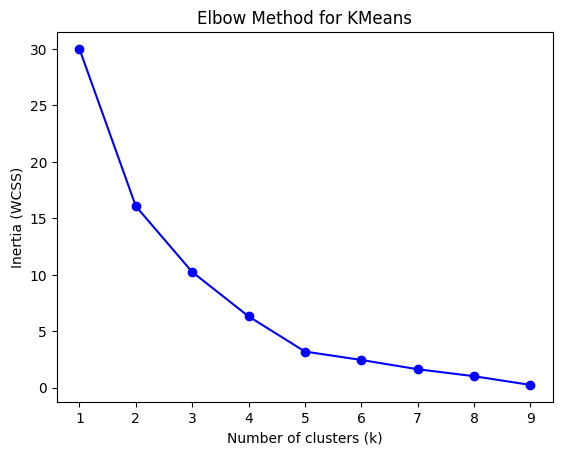

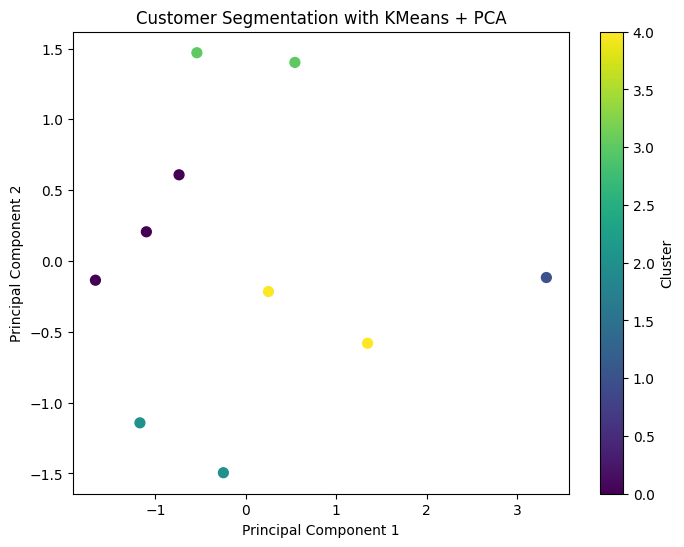

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        0  
2        2  
3        0  
4        4  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- Step 1: Load dataset ---
# (Mall_Customers.csv မှာ columns: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100))
# data = pd.read_csv("Mall_Customers.csv")
dataset = {
    "CustomerID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Gender": ["Male", "Male", "Female", "Female", "Female", "Male", "Male", "Female", "Female", "Male"],
    "Age": [19, 21, 20, 23, 31, 22, 35, 23, 64, 30],
    "Annual Income (k$)": [15, 15, 16, 16, 17, 17, 18, 18, 19, 19],
    "Spending Score (1-100)": [39, 81, 6, 77, 40, 76, 6, 94, 3, 72],
}
data = pd.DataFrame(dataset)
# --- Step 2: Select features for clustering ---
X = data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 3: KMeans clustering ---
# Try different k to check elbow method
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for KMeans")
plt.show()

# --- Step 4: Fit with best k (say k=5) ---
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# --- Step 5: PCA for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", s=50)
plt.title("Customer Segmentation with KMeans + PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Add cluster labels back to dataset
data["Cluster"] = clusters
print(data.head())
